# ARIMA Models

### Load required packages.

In [92]:
from pathlib import Path

import math
import numpy as np
import pandas as pd
import statsmodels.formula.api as sm
# Need to install pmdarima library by applying 
# from terminal the following: pip install pmdarima
import pmdarima as pm
from statsmodels.tsa import tsatools 
from statsmodels.tsa import stattools
from statsmodels.graphics import tsaplots
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from dmba import regressionSummary
import warnings

import matplotlib.pyplot as plt
%matplotlib inline

### Create templates for graph layout.

In [94]:
# Create a template for graph layout with partitions for data set. 
def Graph_Layout_Partition_Data():
    # Determine coordinates for drawing vertical lines and 
    # horizontal arrows on the chart.    
    one_month = pd.Timedelta('31 days')
    xtrain = (min(train_ts.index), max(train_ts.index) - one_month)
    xvalid = (min(valid_ts.index) + one_month, max(valid_ts.index) - one_month)
    xfuture = (max(valid_ts.index) + one_month, '2022')
    xtv = xtrain[1] + 0.7 * (xvalid[0] - xtrain[1])
    xvf = xvalid[1] + 1.0 * (xfuture[0] - xvalid[1])

    ax.axvline(x=xtv, ymin=0, ymax=1, color='black', linewidth=0.5)
    ax.axvline(x=xvf, ymin=0, ymax=1, color='black', linewidth=0.5)

    plt.annotate('', xy=('2013-12', 3300), xytext=('1991', 3300), 
              arrowprops=dict(arrowstyle="<->", shrinkA=0, shrinkB=0))
    plt.annotate('', xy=('2018-12', 3300), xytext=('2014-2', 3300), 
             arrowprops=dict(arrowstyle="<->", shrinkA=0, shrinkB=0))
    plt.annotate('', xy=('2021-12', 3300), xytext=('2019-2', 3300), 
             arrowprops=dict(arrowstyle="<->", shrinkA=0, shrinkB=0))

    # Input text on the arrows.
    ax.text('2001', 3330, 'Training')
    ax.text('2015-1', 3330, 'Validation')
    ax.text('2019-7', 3330, 'Future')

    # Create limits and axis labels.
    ax.set_xlim('1990', '2022')
    ax.set_ylim(1300, 3500)
    ax.set_xlabel('Time')
    ax.set_ylabel('Ridership (in 000s)')

# Create a template for graph layout with partitions for residuals. 
def Graph_Layout_Partition_Residuals():
    # Determine coordinates for drawing vertical lines and 
    # horizontal arrows on the chart.    
    one_month = pd.Timedelta('31 days')
    xtrain = (min(train_ts.index), max(train_ts.index) - one_month)
    xvalid = (min(valid_ts.index) + one_month, max(valid_ts.index) - one_month)
    xfuture = (max(valid_ts.index) + one_month, '2022')
    xtv = xtrain[1] + 0.7 * (xvalid[0] - xtrain[1])
    xvf = xvalid[1] + 1.0 * (xfuture[0] - xvalid[1])

    ax.axvline(x=xtv, ymin=0, ymax=1, color='black', linewidth=0.5)
    ax.axvline(x=xvf, ymin=0, ymax=1, color='black', linewidth=0.5)

    plt.annotate('', xy=('2013-12', 600), xytext=('1991', 600), 
              arrowprops=dict(arrowstyle="<->", shrinkA=0, shrinkB=0))
    plt.annotate('', xy=('2018-12', 600), xytext=('2014-2', 600), 
             arrowprops=dict(arrowstyle="<->", shrinkA=0, shrinkB=0))
    plt.annotate('', xy=('2021-12', 600), xytext=('2019-2', 600), 
             arrowprops=dict(arrowstyle="<->", shrinkA=0, shrinkB=0))

    # Input text on the arrows.
    ax.text('2001', 620, 'Training')
    ax.text('2015-1', 620, 'Validation')
    ax.text('2019-7', 620, 'Future')

    # Create limits and axis labels.
    ax.set_xlim('1990', '2022')
    ax.set_ylim(-600, 700)
    ax.set_xlabel('Time')
    ax.set_ylabel('Ridership (in 000s)')


# Create a template for graph layout with entire dataset and 12 periods 
# into future. 
def Graph_Layout_Entire_Data():
    # Determine coordinates for drawing vertical lines and horizontal 
    # arrows on the chart.
    one_month = pd.Timedelta('31 days')
    xridership = (min(ridership_ts.index), max(ridership_ts.index) - one_month)
    xfuture = (max(ridership_ts.index) + one_month, '2022')
    xvf = xridership[1] + 0.7 * (xfuture[0] - xridership[1])

    ax.axvline(x=xvf, ymin=0, ymax=1, color='black', linewidth=0.5)

    plt.annotate('', xy=('2018-12', 3300), xytext=('1991', 3300), 
              arrowprops=dict(arrowstyle="<->", shrinkA=0, shrinkB=0))
    plt.annotate('', xy=('2021-12', 3300), xytext=('2019-2', 3300), 
             arrowprops=dict(arrowstyle="<->", shrinkA=0, shrinkB=0))

    # Input text on the arrows.
    ax.text('2005', 3330, 'Training')
    ax.text('2019-7', 3330, 'Future')

    # Create limits and axis labels.
    ax.set_xlim('1990', '2022')
    ax.set_ylim(1300, 3500)
    ax.set_xlabel('Time')
    ax.set_ylabel('Ridership (in 000s)')
    

# Create a template for graph layout with entire data for residuals. 
def Graph_Layout_Entire_Data_Residuals():
    # Determine coordinates for drawing vertical lines and 
    # horizontal arrows on the chart.    
    one_month = pd.Timedelta('31 days')
    xridership = (min(ridership_ts.index), max(ridership_ts.index) - one_month)
    xfuture = (max(ridership_ts.index) + one_month, '2022')
    xvf = xridership[1] + 0.7 * (xfuture[0] - xridership[1])

    ax.axvline(x=xvf, ymin=0, ymax=1, color='black', linewidth=0.5)

    plt.annotate('', xy=('2018-12', 600), xytext=('1991', 600), 
             arrowprops=dict(arrowstyle="<->", shrinkA=0, shrinkB=0))
    plt.annotate('', xy=('2021-12', 600), xytext=('2019-2', 600), 
             arrowprops=dict(arrowstyle="<->", shrinkA=0, shrinkB=0))

    # Input text on the arrows.
    ax.text('2005', 620, 'Training')
    ax.text('2019-7', 620, 'Future')

    # Create limits and axis labels.
    ax.set_xlim('1990', '2022')
    ax.set_ylim(-600, 700)
    ax.set_xlabel('Time')
    ax.set_ylabel('Ridership (in 000s)')

### Create measures of forecast accuracy.

In [96]:
# Create forcast accuracy measures.
def Forecast_Accuracy(actual, forecast):
    
    # ME - mean error
    me = round(np.mean(actual - forecast),3) 
    
    # RMSE - root mean square error (RMSE)
    rmse = round((np.mean((actual - forecast)**2)**.5),3)  
   
    # MAE - mean absolute error
    mae = round(np.mean(np.abs(actual - forecast)),3)   
   
    # MPE - mean percentage error,%
    mpe = round(((np.mean((actual - forecast)/actual))*100),3) 
    
    # MAPE - mean absolute percentage error, %
    mape = round(((np.mean(np.abs((actual - forecast)/actual)))*100),3) 
    
    # Ignore unnecessary future warnings on ACF1. 
    warnings.filterwarnings('ignore')
   
    # ACF1 - autocorrelation of errors at lag 1
    acf1 = round((acf(actual - forecast)[1]),3)                 
    
    return({'ME':me, 'RMSE':rmse, 'MAE':mae, 
            'MPE':mpe, 'MAPE':mape, 'ACF1':acf1})

### Create time series data set and identify autocorrelation.

In [98]:
# Create data frame.
Amtrak_data = pd.read_csv('Amtrak_comp.csv')

# Convert the date information to a datetime object as monthly data.
Amtrak_data['Date'] = pd.to_datetime(Amtrak_data.Month, format='%m/%d/%Y')

# Convert data frame column to time series (name is used to label the data).
ridership_ts = pd.Series(Amtrak_data.Ridership.values, 
                         index=Amtrak_data.Date, name='Ridership')

# Define the time series frequency.
ridership_ts.index = pd.DatetimeIndex(ridership_ts.index, 
                         freq=ridership_ts.index.inferred_freq)

# Show/print first 5 records of the time series dataset.
ridership_ts.head()


Date
1991-01-01    1708.917
1991-02-01    1620.586
1991-03-01    1972.715
1991-04-01    1811.665
1991-05-01    1974.964
Freq: MS, Name: Ridership, dtype: float64

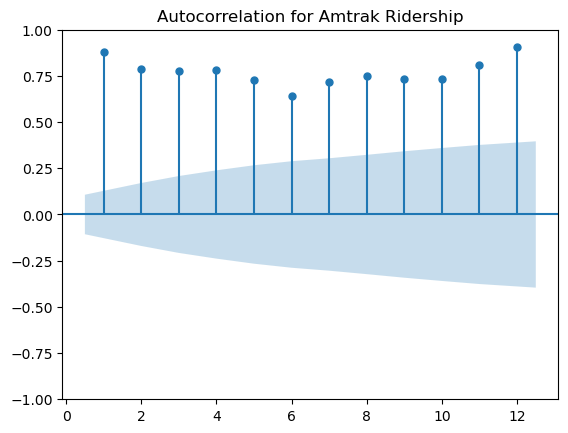

In [99]:
#Use plot_asf() function to identify autocorrelation and plot autocorrelation
#for different lags (up to maximum of 12).

# Display autocorrelation chart. 
#Using specific lags [1, ..., 12] will exclude lag=0. 
interval = [1,2,3,4,5,6,7,8,9,10,11,12]
tsaplots.plot_acf(ridership_ts, lags = interval)
plt.title('Autocorrelation for Amtrak Ridership')

plt.show()

### Create time series partition. 

In [101]:
# Define the numbers of months in the training and validation data sets,
# nTrain and nValid, respectively and create data partition, train_ts
# and valid_ts.
nValid = 60
nTrain = len(ridership_ts) - nValid
train_ts = ridership_ts[:nTrain]
valid_ts = ridership_ts[nTrain:]


### Fit AR(2) model.

In [103]:
# Use ARIMA() function to fit AR(2) model for training period.
# The ARIMA model of order=(2,0,0) gives an AR(2) model.
# Use summary() to show AR(2) model and its parameters. 
train_ar2 = ARIMA(train_ts, order=(2, 0, 0), 
                freq='MS').fit()
print(train_ar2.summary())

# Apply forecast() function to make predictions for ts with 
# AR model in validation set.   
train_ar2_pred = train_ar2.forecast(nValid)
# print(' ')
#train_ar2_pred = train_ar2.predict(start=train_ar2.fittedvalues.shape[0], 
#                   end=train_ar2.fittedvalues.shape[0] + 35)

# Display AR(2) model predictions in validation period. 
print(' ')
print('AR(2) Model Forecast for Validation Period')
print(train_ar2_pred.head())
print('..........')
print(train_ar2_pred.tail())


                               SARIMAX Results                                
Dep. Variable:              Ridership   No. Observations:                  276
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1818.502
Date:                Thu, 16 Jan 2025   AIC                           3645.004
Time:                        17:36:06   BIC                           3659.486
Sample:                    01-01-1991   HQIC                          3650.816
                         - 12-01-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2043.5373     88.236     23.160      0.000    1870.598    2216.477
ar.L1          0.7583      0.091      8.300      0.000       0.579       0.937
ar.L2          0.1234      0.088      1.396      0.1

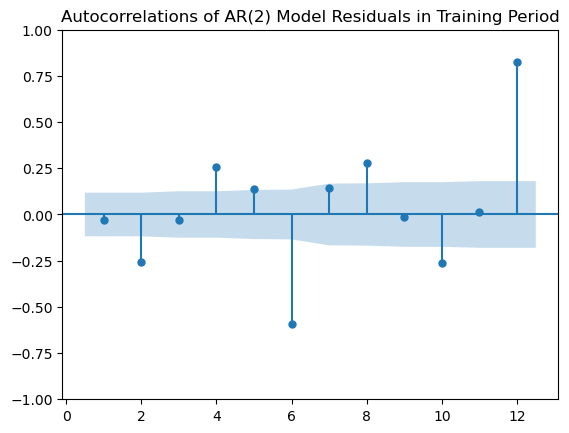

In [104]:
#Use plot_asf() function to identify autocorrelation for 
# AR(2) model residuals and plot autocorrelation
#for different lags (up to maximum of 12).

# Identify residuals for AR(2) in training partition.
train_ar2_res = train_ar2.resid

# Display autocorrelation chart. 
#Using specific lags [1, ..., 12] will exclude lag=0. 
interval = [1,2,3,4,5,6,7,8,9,10,11,12]
tsaplots.plot_acf(train_ar2_res, lags = interval)
plt.title('Autocorrelations of AR(2) Model Residuals in Training Period')

plt.show()

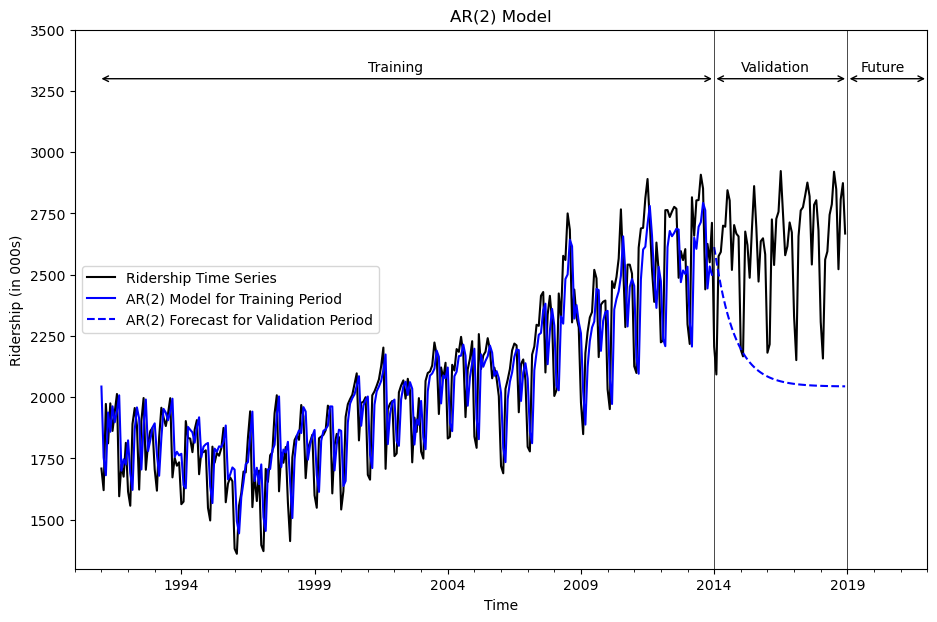

In [105]:
# Plot ts data, AR model, and predictions for validation period.

# Plot entire data set that combines training and validation.
ax = ridership_ts.plot(color='black', linewidth=1.5, figsize=(11,7))


# Plot AR model for training and valiation sets.
train_ar2.fittedvalues.plot(ax = ax, color="blue", linewidth=1.5)
train_ar2_pred.plot(ax = ax, color="blue", style='--', linewidth=1.5)

# Use template of graph layout for partitions. 
Graph_Layout_Partition_Data()

# Create graph legend and title.
ax.legend(['Ridership Time Series', 'AR(2) Model for Training Period', 
           'AR(2) Forecast for Validation Period'],
         loc = 'center left')
plt.title('AR(2) Model')

plt.show()

### Fit MA(2) model.

In [107]:
# Use ARIMA() function to fit MA(2) model for training period.
# The ARIMA model of order=(0,0,2) gives an MA(2) model.
# Use summary() to show MA(2) model and its parameters. 
train_ma2 = ARIMA(train_ts, order=(0, 0, 2), 
                freq='MS').fit()
print(train_ma2.summary())

# Apply forecast() function to make predictions for ts with 
# MA model in validation set.   
train_ma2_pred = train_ma2.forecast(nValid)
#train_ma2_pred = train_ma2.predict(start=train_ma2.fittedvalues.shape[0], 
#                   end=train_ma2.fittedvalues.shape[0] + 35)


# Display MA(2) Model forecast in validation period. 
print(' ')
print('MA(2) Model Forecast for Validation Period')
print(train_ma2_pred.head())
print('..........')
print(train_ma2_pred.tail())

                               SARIMAX Results                                
Dep. Variable:              Ridership   No. Observations:                  276
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -1851.670
Date:                Thu, 16 Jan 2025   AIC                           3711.341
Time:                        17:36:08   BIC                           3725.822
Sample:                    01-01-1991   HQIC                          3717.152
                         - 12-01-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2043.5908     32.921     62.075      0.000    1979.066    2108.116
ma.L1          0.9060      0.046     19.670      0.000       0.816       0.996
ma.L2          0.6914      0.047     14.664      0.0

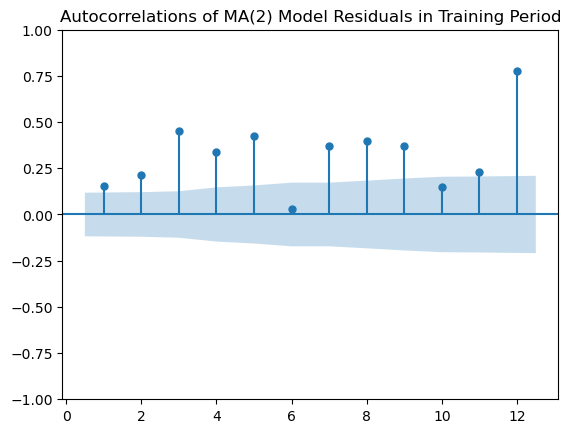

In [108]:
#Use plot_asf() function to identify autocorrelation for 
# MA(2) model residuals and plot autocorrelation
#for different lags (up to maximum of 12).

# Identify residuals for MA(2) in training partition.
train_ma2_res = train_ma2.resid

# Diaplay autocorrelation chart.
# Using specific lags [1, ..., 12] will exclude lag=0. 
# interval = [1,2,3,4,5,6,7,8,9,10,11,12]
tsaplots.plot_acf(train_ma2_res, lags = interval)
plt.title('Autocorrelations of MA(2) Model Residuals in Training Period')

plt.show()

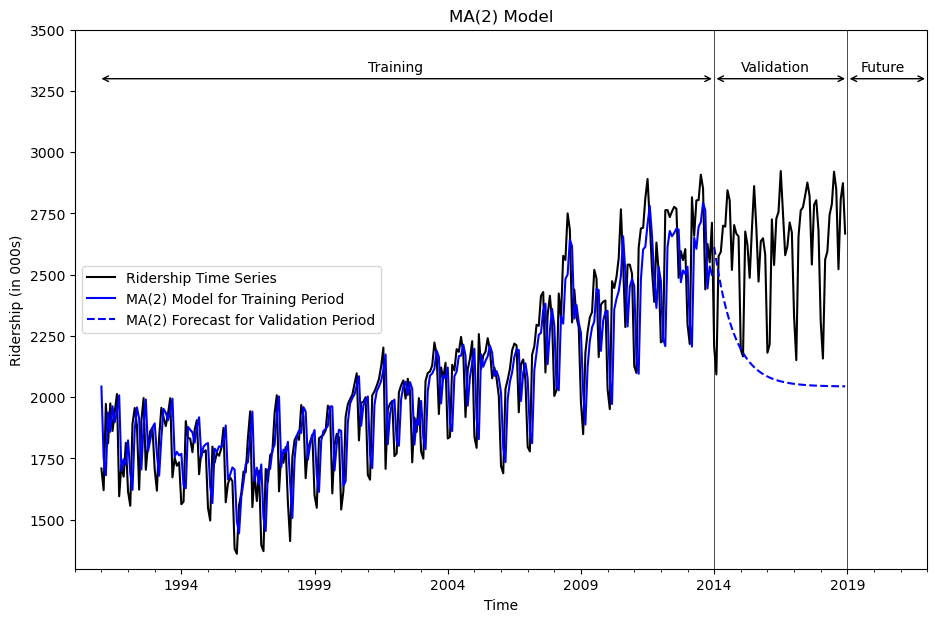

In [109]:
# Plot ts data, MA model, and predictions for validation period.

# Plot entire data set that combines training and validation.
ax = ridership_ts.plot(color='black', linewidth=1.5, figsize=(11,7))


# Plot MA model for training and valiation sets.
train_ar2.fittedvalues.plot(ax = ax, color="blue", linewidth=1.5)
train_ar2_pred.plot(ax = ax, color="blue", style='--', linewidth=1.5)

# Use template of graph layout for partitions. 
Graph_Layout_Partition_Data()

# Create graph legend and title.
ax.legend(['Ridership Time Series', 'MA(2) Model for Training Period', 
           'MA(2) Forecast for Validation Period'],
         loc = 'center left')
plt.title('MA(2) Model')

plt.show()

### Fit ARMA(2, 2) model.

In [111]:
# Use ARIMA() function to fit ARMA(2,2) model for training period.
# The ARIMA model of order=(2,0,2) gives an ARMA(2,2) model.
# Use summary() to show ARMA(2,2) model and its parameters. 
train_arma2 = ARIMA(train_ts, order=(2, 0, 2), 
                freq='MS').fit()
print(train_arma2.summary())

# Apply forecast() function to make predictions for ts with 
# ARMA model in validation set.   
train_arma2_pred = train_arma2.forecast(nValid)
#train_arma2_pred = train_arma2.predict(start=train_arma2.fittedvalues.shape[0], 
#                   end=train_arma2.fittedvalues.shape[0] + 35)

# Display ARMA(2,2) forecast for validation period.
print(' ')
print('ARMA(2,2) Model Forecast for Validation Period')
print(train_arma2_pred.head())
print('..........')
print(train_arma2_pred.tail())

                               SARIMAX Results                                
Dep. Variable:              Ridership   No. Observations:                  276
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -1794.642
Date:                Thu, 16 Jan 2025   AIC                           3601.285
Time:                        17:36:10   BIC                           3623.007
Sample:                    01-01-1991   HQIC                          3610.002
                         - 12-01-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2043.6245    460.437      4.438      0.000    1141.184    2946.065
ar.L1          1.1867      0.130      9.141      0.000       0.932       1.441
ar.L2         -0.1883      0.129     -1.465      0.1

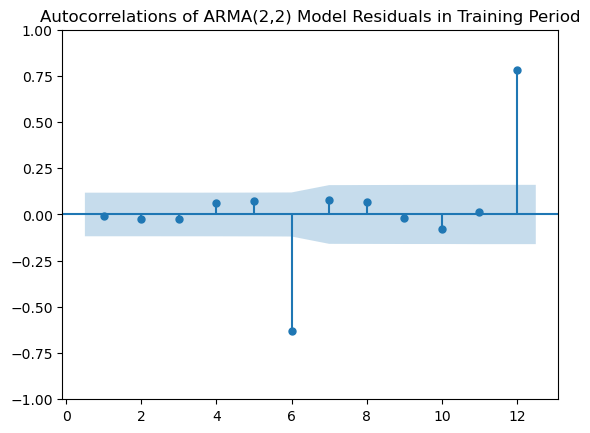

In [112]:
#Use plot_asf() function to identify autocorrelation for 
# ARMA(2,2) model residuals and plot autocorrelation
#for different lags (up to maximum of 12).

# Identify residuals for ARMA(2,2) in training partition.
train_arma2_res = train_arma2.resid

# Diaplay autocorrelation chart.
# Using specific lags [1, ..., 12] will exclude lag=0. 
# interval = [1,2,3,4,5,6,7,8,9,10,11,12]
tsaplots.plot_acf(train_arma2_res, lags = interval)
plt.title('Autocorrelations of ARMA(2,2) Model Residuals in Training Period')

plt.show()

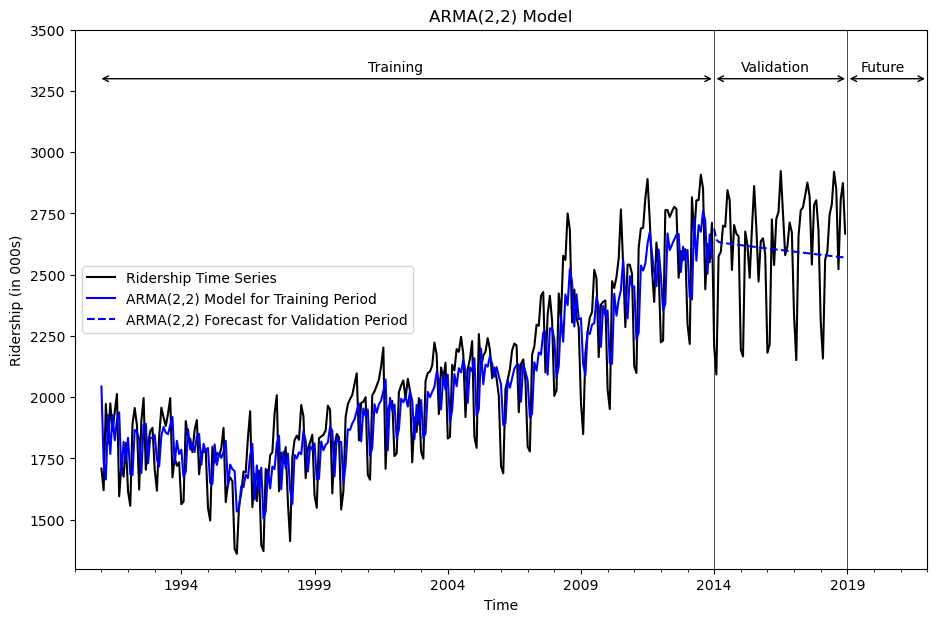

In [113]:
# Plot ts data, ARMA model, and predictions for validation period.

# Plot entire data set that combines training and validation.
ax = ridership_ts.plot(color='black', linewidth=1.5, figsize=(11,7))


# Plot ARMA model for training and valiation sets.
train_arma2.fittedvalues.plot(ax = ax, color="blue", linewidth=1.5)
train_arma2_pred.plot(ax = ax, color="blue", style='--', linewidth=1.5)

# Use template of graph layout for partitions. 
Graph_Layout_Partition_Data()

# Create graph legend and title.
ax.legend(['Ridership Time Series', 'ARMA(2,2) Model for Training Period', 
           'ARMA(2,2) Forecast for Validation Period'],
         loc = 'center left')
plt.title('ARMA(2,2) Model')

plt.show()

### Fit ARIMA(2, 1, 2) model.

In [115]:
# Use ARIMA() function to fit ARIMA(2,1,2) model for training period.
# Use summary() to show ARIMA(2,1,2) model and its parameters. 
train_arima = ARIMA(train_ts, order=(2, 1, 2), freq='MS',
              enforce_stationarity=False, 
              enforce_invertibility=False).fit()
print(train_arima.summary())

# Apply forecast() function to make predictions for ts with 
# ARIMA (2,1,2) model in validation set.   
train_arima_pred = train_arima.forecast(nValid)
#train_arma2_pred = train_arma2.predict(start=train_arma2.fittedvalues.shape[0], 
#                   end=train_arma2.fittedvalues.shape[0] + 35)

# Display ARIMA(2,1,2) forecast for validation period.
print(' ')
print('ARIMA(2,1,2) Model Forecast for Validation Period')
print(train_arima_pred.head())
print('..........')
print(train_arima_pred.tail())


                               SARIMAX Results                                
Dep. Variable:              Ridership   No. Observations:                  276
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -1780.549
Date:                Thu, 16 Jan 2025   AIC                           3571.097
Time:                        17:36:11   BIC                           3589.126
Sample:                    01-01-1991   HQIC                          3578.335
                         - 12-01-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0472      0.060     17.593      0.000       0.930       1.164
ar.L2         -0.6877      0.062    -11.012      0.000      -0.810      -0.565
ma.L1         -1.4089      0.034    -41.898      0.0

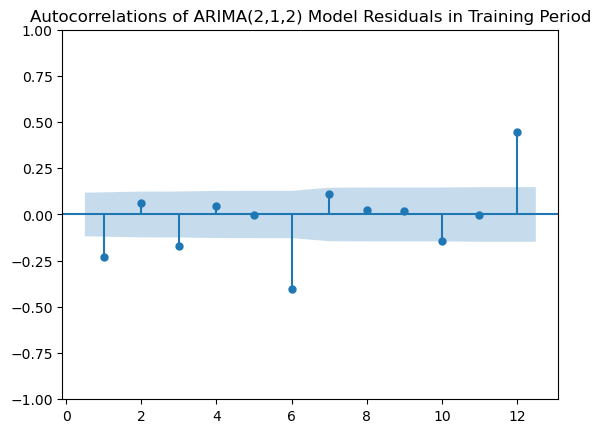

In [116]:
#Use plot_asf() function to identify autocorrelation for 
# ARIMA(2,1,2) model residuals and plot autocorrelation
#for different lags (up to maximum of 12).

# Identify residuals for ARIMA(2,1,2) in training partition.
train_arima_res = train_arima.resid

# Diaplay autocorrelation chart.
# Using specific lags [1, ..., 12] will exclude lag=0. 
# interval = [1,2,3,4,5,6,7,8,9,10,11,12]
tsaplots.plot_acf(train_arima_res, lags = interval)
plt.title('Autocorrelations of ARIMA(2,1,2) Model Residuals in Training Period')

plt.show()

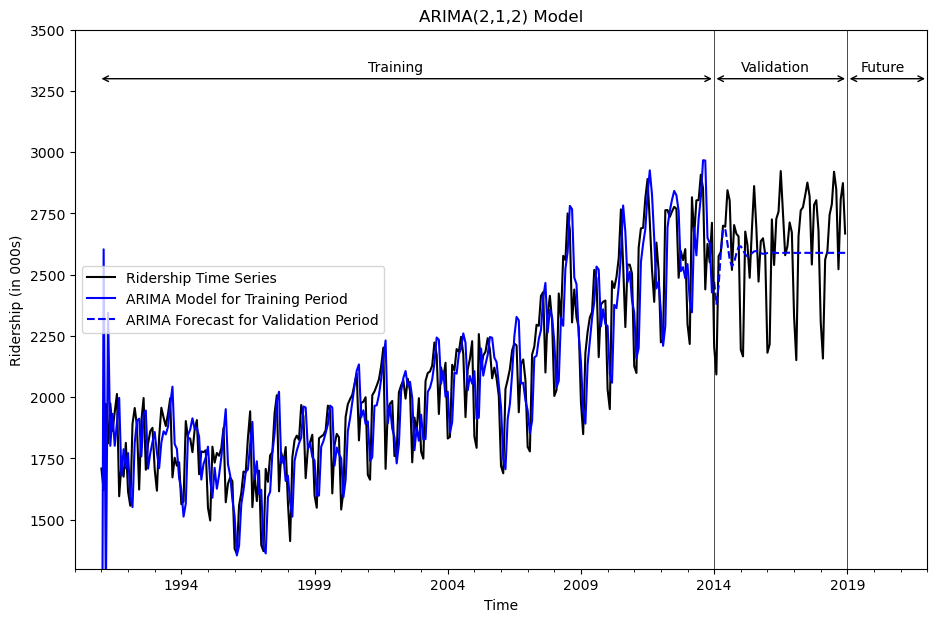

In [117]:
# Plot ts data, ARIMA (2,1,2) model, and predictions for validation period.

# Plot entire data set that combines training and validation.
ax = ridership_ts.plot(color='black', linewidth=1.5, figsize=(11,7))


# Plot ARIMA model for training and valiation sets.
train_arima.fittedvalues.plot(ax = ax, color="blue", linewidth=1.5)
train_arima_pred.plot(ax = ax, color="blue", style='--', linewidth=1.5)

# Use template of graph layout for partitions. 
Graph_Layout_Partition_Data()

# Create graph legend and title.
ax.legend(['Ridership Time Series', 'ARIMA Model for Training Period', 
           'ARIMA Forecast for Validation Period'],
         loc = 'center left')
plt.title('ARIMA(2,1,2) Model')

plt.show()

### Fit ARIMA(2, 1, 2)(1,1,2) model.

In [119]:
# Use ARIMA() function to fit seasonal ARIMA(2,1,2)(1,1,2) 
# model for trend and seasonality in training period.
# Use summary() to show ARIMA model and its parameters. 
train_arima_seas = SARIMAX(train_ts, order=(2, 1, 2), 
              seasonal_order=(1,1,2,12)).fit(maxiter=1000, disp=False)
print(train_arima_seas.summary())

# Apply forecast() function to make predictions for ts with 
# seasonal ARIMA model in validation set. 
train_arima_seas_pred = train_arima_seas.forecast(nValid)

# Display seasonal ARIMA(2,1,2)(1,1,2) forecast for validation period.
print(' ')
print('ARIMA(2,1,2)(1,1,2) Model Forecast for Validation Period')
print(train_arima_seas_pred.head())
print('..........')
print(train_arima_seas_pred.tail())


                                     SARIMAX Results                                      
Dep. Variable:                          Ridership   No. Observations:                  276
Model:             SARIMAX(2, 1, 2)x(1, 1, 2, 12)   Log Likelihood               -1492.844
Date:                            Thu, 16 Jan 2025   AIC                           3001.689
Time:                                    17:36:31   BIC                           3030.266
Sample:                                01-01-1991   HQIC                          3013.174
                                     - 12-01-2013                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0085      0.150     -6.720      0.000      -1.303      -0.714
ar.L2         -0.0180      0.143   

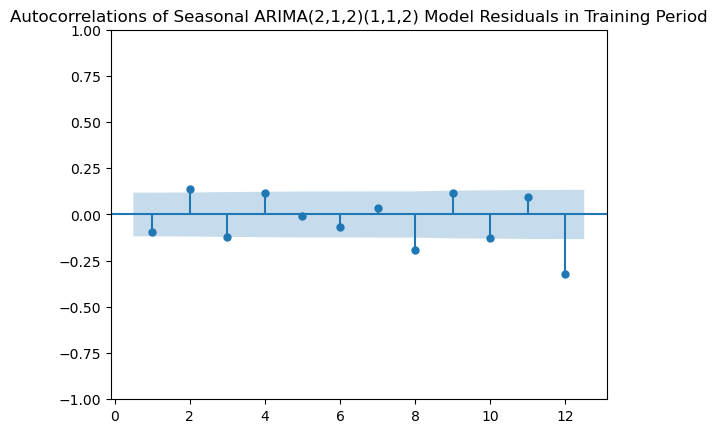

In [120]:
#Use plot_asf() function to identify autocorrelation for 
# seasonal ARIMA(2,1,2)(1,1,2) model residuals and plot 
# autocorrelation for different lags (up to maximum of 12).

# Identify residuals for ARIMA(2,1,2)(1,1,2) in training partition.
train_arima_seas_res = train_arima_seas.resid

# Diaplay autocorrelation chart.
# Using specific lags [1, ..., 12] will exclude lag=0. 
# interval = [1,2,3,4,5,6,7,8,9,10,11,12]
tsaplots.plot_acf(train_arima_seas_res, lags = interval)
plt.title('Autocorrelations of Seasonal ARIMA(2,1,2)(1,1,2) Model Residuals in Training Period')

plt.show()

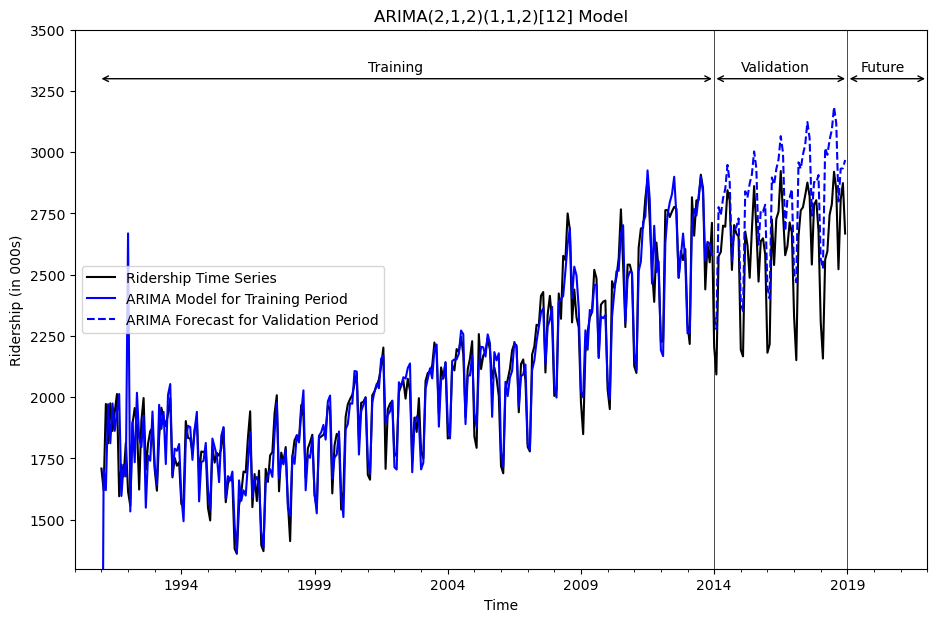

In [121]:
# Plot ts data, ARIMA model, and predictions for validation period.

# Plot entire data set that combines training and validation.
ax = ridership_ts.plot(color='black', linewidth=1.5, figsize=(11,7))


# Plot ARIMA model for training and valiation sets.
train_arima_seas.fittedvalues.plot(ax = ax, color="blue", linewidth=1.5)
train_arima_seas_pred.plot(ax = ax, color="blue", style='--', linewidth=1.5)

# Use template of graph layout for partitions. 
Graph_Layout_Partition_Data()

# Create graph legend and title.
ax.legend(['Ridership Time Series', 'ARIMA Model for Training Period', 
           'ARIMA Forecast for Validation Period'],
         loc = 'center left')
plt.title('ARIMA(2,1,2)(1,1,2)[12] Model')

plt.show()

### Fit Auto ARIMA model.

In [123]:
# Use auto_arima() function to fit ARIMA model for training data
# to identify the optimal values of all ARIMA parameters for 
# trend and seasonality. 
train_auto_arima = pm.auto_arima(train_ts, 
                         start_p=1,  d=None, start_q=1, #Model start.
                         test='adf', #Use adftest to find optimal 'd'.
                         max_p=3, max_q=3, #Maximum p and q.  
                         m=12,  #Frequency of time series.
                         seasonal=True, #Allow for seasonality.
                         start_P=0, D=1, start_Q=0,#For seasonlity,D=1.
                         trace=True,  
                         error_action='ignore',  
                         suppress_warnings=True, 
                         stepwise=True) #Stepwise search for min AIC.

# Use summary() to show auto ARIMA optimal parameters. 
print(train_auto_arima.summary())


Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=3077.517, Time=0.53 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=3256.992, Time=0.09 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=3065.291, Time=0.99 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=3142.163, Time=1.22 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=3282.195, Time=0.08 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=3095.229, Time=0.48 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=3047.181, Time=3.87 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=3032.378, Time=3.77 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=3031.612, Time=1.30 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=3033.129, Time=0.87 sec
 ARIMA(1,0,0)(1,1,2)[12] intercept   : AIC=3032.526, Time=5.67 sec
 ARIMA(1,0,0)(0,1,2)[12] intercept   : AIC=3031.008, Time=3.23 sec
 ARIMA(0,0,0)(0,1,2)[12] intercept   : AIC=3241.895, Time=1.18 sec
 ARIMA(2,0,0)(0,1,2)[12] intercept   : AIC=3006.373, Time=3.10 sec
 ARIMA(2,0,0)(0,1,1

In [124]:
# Based on the optimal auto ARIMA parameters, apply ARIMA()
# function to fit optimal ARIMA model for training data.
train_auto_arima = SARIMAX(train_ts, order=(1, 0, 1), 
              seasonal_order=(0,1,1,12)).fit()

# Use summary() to show optimal ARIMA parameters. 
print(train_auto_arima.summary())

# Apply forecast() function to make predictions for ts with 
# ARIMA model in validation set. 
train_auto_arima_pred = train_auto_arima.forecast(nValid)

# Display Auto ARIMA forecast for validation period.
print(' ')
print('Auto ARIMA Forecast for Validation Period')
print(train_auto_arima_pred.head())
print('..........')
print(train_auto_arima_pred.tail())

                                     SARIMAX Results                                      
Dep. Variable:                          Ridership   No. Observations:                  276
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 12)   Log Likelihood               -1500.237
Date:                            Thu, 16 Jan 2025   AIC                           3008.473
Time:                                    17:37:36   BIC                           3022.777
Sample:                                01-01-1991   HQIC                          3014.221
                                     - 12-01-2013                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9666      0.016     59.000      0.000       0.934       0.999
ma.L1         -0.4375      0.054   

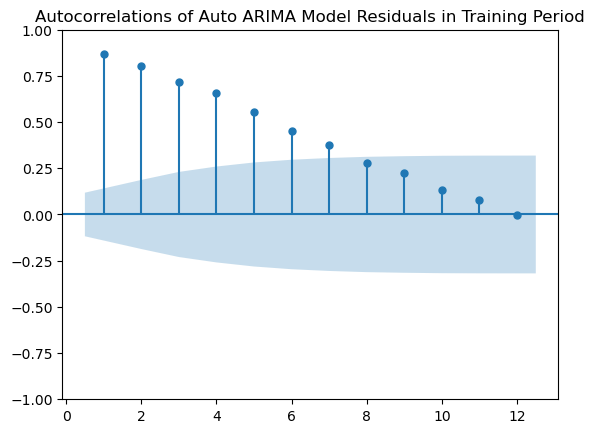

In [125]:
#Use plot_asf() function to identify autocorrelation for 
# auto ARIMA model residuals and plot autocorrelation
#for different lags (up to maximum of 12).

# Identify residuals for auto ARIMA in training partition.
train_auto_arima_res = train_auto_arima.resid

# Diaplay autocorrelation chart.
# Using specific lags [1, ..., 12] will exclude lag=0. 
# interval = [1,2,3,4,5,6,7,8,9,10,11,12]
tsaplots.plot_acf(train_auto_arima_res, lags = interval)
plt.title('Autocorrelations of Auto ARIMA Model Residuals in Training Period')

plt.show()

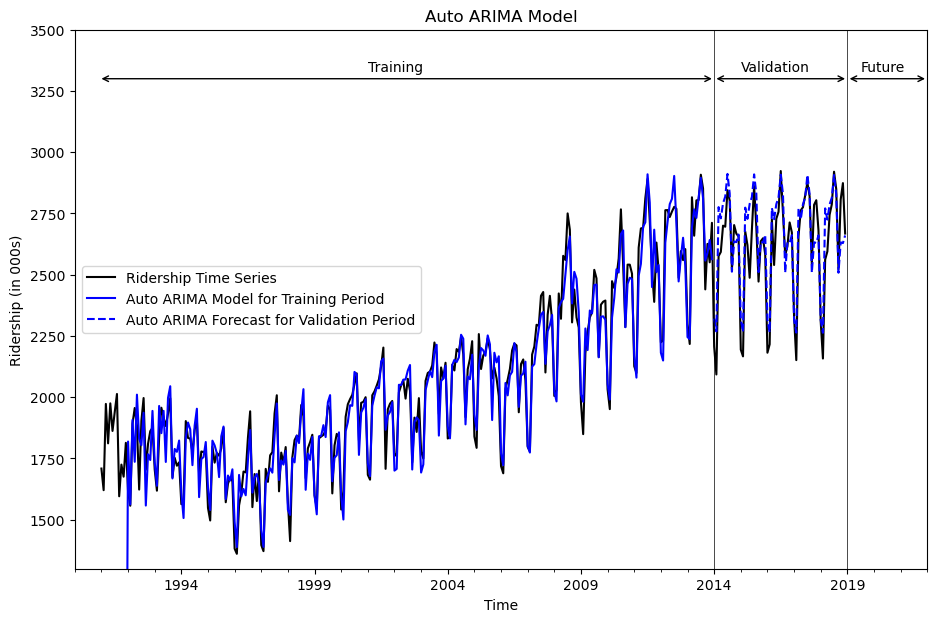

In [126]:
# Plot ts data, auto ARIMA model, and predictions for validation period.

# Plot entire data set that combines training and validation.
ax = ridership_ts.plot(color='black', linewidth=1.5, figsize=(11,7))

# Plot auto ARIMA model for training and valiation sets.
train_auto_arima.fittedvalues.plot(ax = ax, color="blue", linewidth=1.5)
train_auto_arima_pred.plot(ax = ax, color="blue", style='--', linewidth=1.5)

# Use template of graph layout for partitions. 
Graph_Layout_Partition_Data()

# Create graph legend and title.
ax.legend(['Ridership Time Series', 'Auto ARIMA Model for Training Period', 
           'Auto ARIMA Forecast for Validation Period'],
         loc = 'center left')
plt.title('Auto ARIMA Model')

plt.show()


In [127]:
# Use Forecast_Accuracy(actual, forecast) function 
# defined in this file to identfiy common accuracy
# measures for AR(2) in validation period.
print("Accuracy Measures for AR(2) Model")
print(Forecast_Accuracy(valid_ts, train_ar2_pred))

# Use Forecast_Accuracy(actual, forecast) function 
# defined in this file to identfiy common accuracy 
# measures for MA(2) in validation period..
print(' ')
print("Accuracy Measures for MA(2) Model")
print(Forecast_Accuracy(valid_ts, train_ma2_pred))

# Use Forecast_Accuracy(actual, forecast) function 
# defined in this file to identfiy common accuracy 
# measures for ARMA(2,2) in validation period.
print(' ')
print("Accuracy Measures for ARMA(2,2) Model")
print(Forecast_Accuracy(valid_ts, train_arma2_pred))

# Use Forecast_Accuracy(actual, forecast) function 
# defined in this file to identfiy common accuracy 
# measures for ARIMA(2,1,2) in validation period.
print(' ')
print("Accuracy Measures for ARIMA(2,1,2) Model")
print(Forecast_Accuracy(valid_ts, train_arima_pred))

# Use Forecast_Accuracy(actual, forecast) function 
# defined in this file to identfiy common accuracy 
# measures for ARIMA(2,1,2)(1,1,2) in validation period.
print(' ')
print("Accuracy Measures for ARIMA(2,1,2)(1,1,2) Model")
print(Forecast_Accuracy(valid_ts, train_arima_seas_pred))

# Use Forecast_Accuracy(actual, forecast) function 
# defined in this file to identfiy common accuracy 
# measures for auto ARIMA in validation period.
print(' ')
print("Accuracy Measures for Auto ARIMA Model")
print(Forecast_Accuracy(valid_ts, train_auto_arima_pred))

Accuracy Measures for AR(2) Model
{'ME': 481.332, 'RMSE': 559.323, 'MAE': 510.948, 'MPE': 17.659, 'MAPE': 19.04, 'ACF1': 0.618}
 
Accuracy Measures for MA(2) Model
{'ME': 564.022, 'RMSE': 612.315, 'MAE': 574.789, 'MPE': 20.903, 'MAPE': 21.401, 'ACF1': 0.469}
 
Accuracy Measures for ARMA(2,2) Model
{'ME': 13.833, 'RMSE': 223.51, 'MAE': 174.572, 'MPE': -0.238, 'MAPE': 6.975, 'ACF1': 0.481}
 
Accuracy Measures for ARIMA(2,1,2) Model
{'ME': 32.519, 'RMSE': 208.121, 'MAE': 166.977, 'MPE': 0.554, 'MAPE': 6.605, 'ACF1': 0.431}
 
Accuracy Measures for ARIMA(2,1,2)(1,1,2) Model
{'ME': -194.998, 'RMSE': 216.536, 'MAE': 195.685, 'MPE': -7.58, 'MAPE': 7.605, 'ACF1': 0.57}
 
Accuracy Measures for Auto ARIMA Model
{'ME': -38.601, 'RMSE': 104.419, 'MAE': 79.37, 'MPE': -1.631, 'MAPE': 3.107, 'ACF1': 0.592}


### Fit seasonal ARIMA and auto ARIMA model for entire data set.  Forecast and plot data, and measure accuracy. 

In [129]:
# Use ARIMA() function to fit seasonal ARIMA(2,1,2)(1,1,2) 
# model for trend and seasonality for entire data set.
# Use summary() to show ARIMA model and its parameters. 
arima_seas = SARIMAX(ridership_ts, order=(2, 1, 2), 
              seasonal_order=(1,1,2,12)).fit()
print(arima_seas.summary())

# Apply predict() function to make predictions for ts with 
# seasonal ARIMA (2,1,2)(1,1,2) model for future 12 periods.  
arima_seas_pred = arima_seas.predict(\
            start=arima_seas.fittedvalues.shape[0], 
            end=arima_seas.fittedvalues.shape[0] + 11) 

# Display ARIMA(2,1,2)(1,1,2) forecast for future 12 periods.
print(' ')
print('ARIMA(2,1,2)(1,1,2) Model Forecast for Future 12 Periods')
arima_seas_pred


                                     SARIMAX Results                                      
Dep. Variable:                          Ridership   No. Observations:                  336
Model:             SARIMAX(2, 1, 2)x(1, 1, 2, 12)   Log Likelihood               -1836.613
Date:                            Thu, 16 Jan 2025   AIC                           3689.227
Time:                                    17:37:47   BIC                           3719.448
Sample:                                01-01-1991   HQIC                          3701.291
                                     - 12-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6936      0.269      2.576      0.010       0.166       1.221
ar.L2          0.0982      0.145   

2019-01-01    2336.004217
2019-02-01    2253.299878
2019-03-01    2716.594059
2019-04-01    2704.517627
2019-05-01    2802.245607
2019-06-01    2835.384005
2019-07-01    2966.298228
2019-08-01    2870.018310
2019-09-01    2602.543593
2019-10-01    2794.973901
2019-11-01    2820.150195
2019-12-01    2737.435558
Freq: MS, Name: predicted_mean, dtype: float64

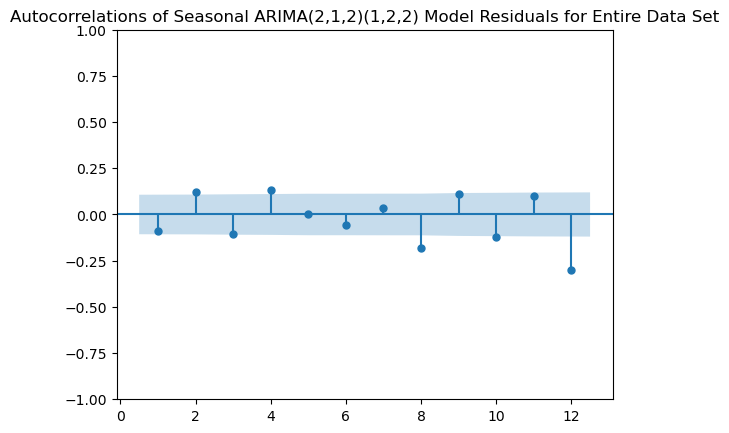

In [130]:
#Use plot_asf() function to identify autocorrelation for 
# seasonal ARIMA(2,1,2)(1,1,2) model residuals and plot 
# autocorrelation for different lags (up to maximum of 12).

# Identify residuals for ARIMA(2,1,2)(1,1,2) in training partition.
arima_seas_res = arima_seas.resid

# Diaplay autocorrelation chart.
# Using specific lags [1, ..., 12] will exclude lag=0. 
# interval = [1,2,3,4,5,6,7,8,9,10,11,12]
tsaplots.plot_acf(arima_seas_res, lags = interval)
plt.title('Autocorrelations of Seasonal ARIMA(2,1,2)(1,2,2) \
Model Residuals for Entire Data Set')

plt.show()

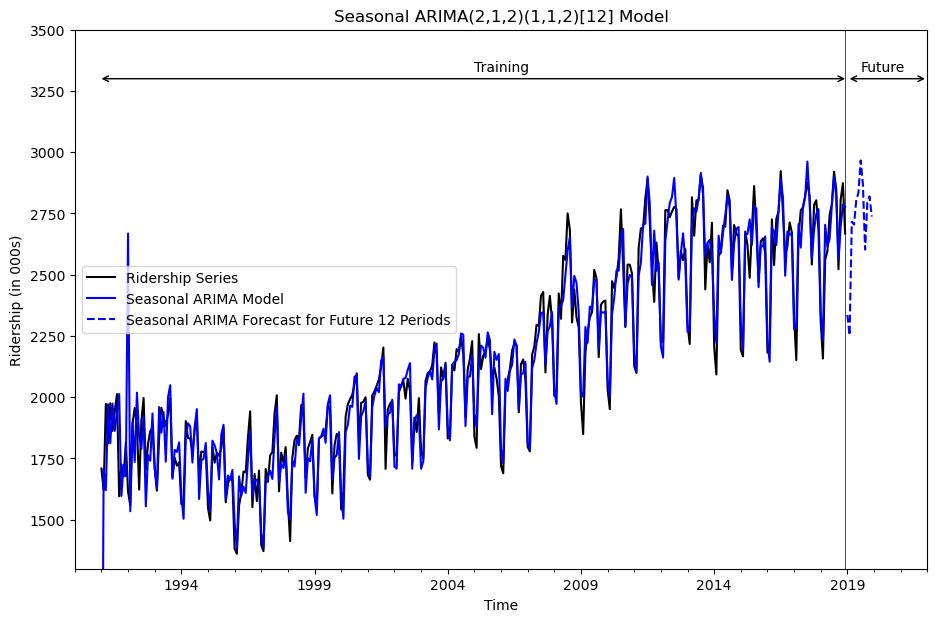

In [131]:
# Plot ts data, ARIMA model, and predictions for validation period.

# Plot entire data set.
ax = ridership_ts.plot(color='black', linewidth=1.5, figsize=(11,7))

# Plot seasonal ARIMA(2,1,2)(1,1,2) model for entire data set 
# and future 12 periods.
arima_seas.fittedvalues.plot(ax = ax, color="blue", linewidth=1.5)
arima_seas_pred.plot(ax = ax, color="blue", style='--', linewidth=1.5)

# Use template of graph layout for entire data. 
Graph_Layout_Entire_Data()

# Create graph legend and title.
ax.legend(['Ridership Series', 'Seasonal ARIMA Model', 
           'Seasonal ARIMA Forecast for Future 12 Periods'],
          loc = 'center left')
plt.title('Seasonal ARIMA(2,1,2)(1,1,2)[12] Model')

plt.show()

In [132]:
# Use auto_arima() function to fit ARIMA model for training data
# to identify the optimal values of all ARIMA parameters for 
# trend and seasonality. 
auto_arima = pm.auto_arima(ridership_ts, 
             start_p=1,  d=None, start_q=1, #Model start.
             test='adf', #Use adftest to find optimal 'd'.
             max_p=3, max_q=3, #Maximum p and q.  
             m=12,  #Frequency of time series.
             seasonal=True, #Allow for seasonality.
             start_P=0, D=1, start_Q=0,#For seasonlity,D=1.
             trace=True,  
             error_action='ignore',  
             suppress_warnings=True, 
             stepwise=True) #Stepwise search for min AIC.

# Use summary() to show auto ARIMA optimal parameters. 
print(auto_arima.summary())

# Best model is different from R's best auto ARIMA model.

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=3794.639, Time=0.64 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=3980.066, Time=0.07 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=3777.501, Time=0.99 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=3849.952, Time=1.15 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=4002.223, Time=0.05 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=3817.600, Time=0.16 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=3751.043, Time=4.28 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=3726.885, Time=4.90 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=3727.172, Time=1.09 sec
 ARIMA(1,0,0)(2,1,2)[12] intercept   : AIC=3729.172, Time=6.37 sec
 ARIMA(1,0,0)(1,1,2)[12] intercept   : AIC=3727.115, Time=4.72 sec
 ARIMA(0,0,0)(2,1,1)[12] intercept   : AIC=3950.256, Time=2.21 sec
 ARIMA(2,0,0)(2,1,1)[12] intercept   : AIC=3701.412, Time=4.83 sec
 ARIMA(2,0,0)(1,1,1)[12] intercept   : AIC=3700.732, Time=1.33 sec
 ARIMA(2,0,0)(0,1,1

In [133]:
# Based on the auto ARIMA parameters, apply ARIMA()
# function to fit auto ARIMA model for entire data set.

auto_arima = SARIMAX(ridership_ts, order=(1, 0, 1), 
              seasonal_order=(0,1,2,12)).fit()

# Use summary() to show optimal ARIMA parameters. 
print(auto_arima.summary())

# Apply predict() function to make predictions for ts with 
# auto ARIMA model in 12 future periods.  
auto_arima_pred = auto_arima.predict(\
            start=auto_arima.fittedvalues.shape[0], 
            end=auto_arima.fittedvalues.shape[0] + 11) 
                         
print(' ')
print('Auto ARIMA Forecast for Future 12 Periods')
auto_arima_pred

                                        SARIMAX Results                                        
Dep. Variable:                               Ridership   No. Observations:                  336
Model:             SARIMAX(1, 0, 1)x(0, 1, [1, 2], 12)   Log Likelihood               -1845.614
Date:                                 Thu, 16 Jan 2025   AIC                           3701.227
Time:                                         17:40:00   BIC                           3720.131
Sample:                                     01-01-1991   HQIC                          3708.773
                                          - 12-01-2018                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9680      0.015     66.544      0.000       0.939       0

2019-01-01    2335.216512
2019-02-01    2236.801743
2019-03-01    2699.981924
2019-04-01    2691.268645
2019-05-01    2774.735054
2019-06-01    2822.630443
2019-07-01    2943.072566
2019-08-01    2851.863149
2019-09-01    2566.113360
2019-10-01    2760.677167
2019-11-01    2796.480173
2019-12-01    2695.631625
Freq: MS, Name: predicted_mean, dtype: float64

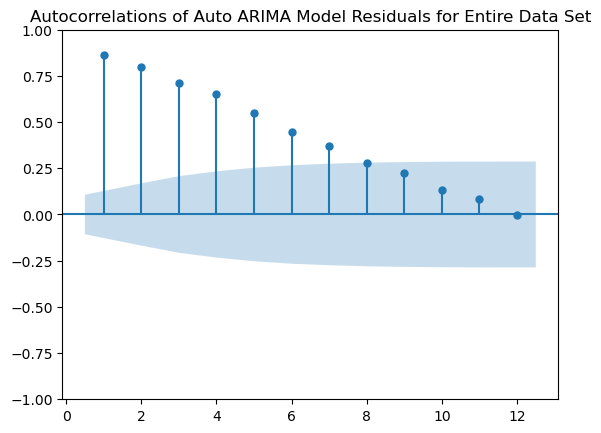

In [134]:
#Use plot_asf() function to identify autocorrelation for 
# auto ARIMA model residuals and plot autocorrelation
#for different lags (up to maximum of 12).

# Identify residuals for auto ARIMA for entire data set.
auto_arima_res = auto_arima.resid

# Diaplay autocorrelation chart.
# Using specific lags [1, ..., 12] will exclude lag=0. 
# interval = [1,2,3,4,5,6,7,8,9,10,11,12]
tsaplots.plot_acf(auto_arima_res, lags = interval)
plt.title('Autocorrelations of Auto ARIMA Model Residuals for Entire Data Set')

plt.show()

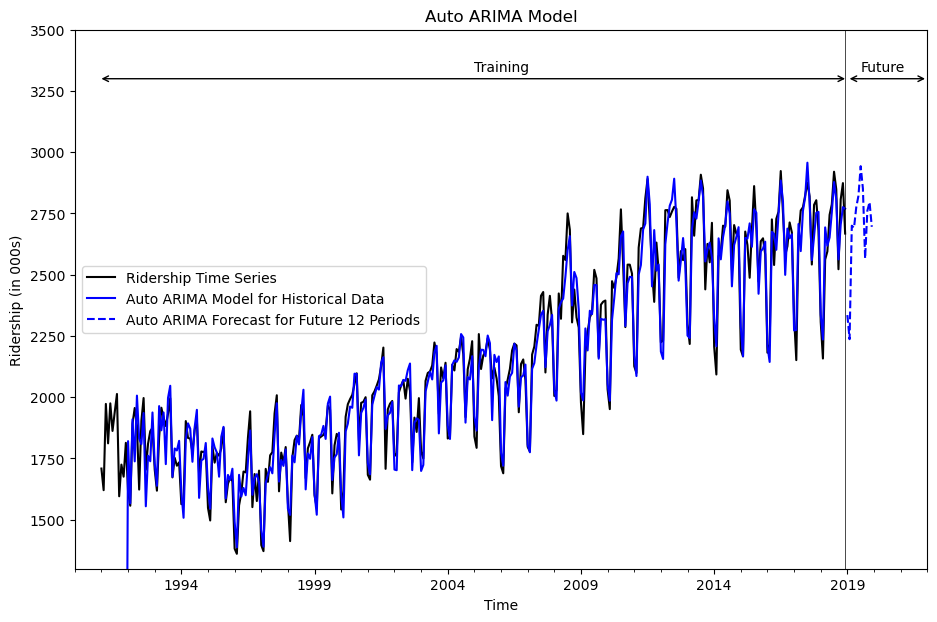

In [135]:
# Plot historical data, auto ARIMA model predictions for 
# entire data set and future 12 periods.

# Plot entire data set that combines training and validation.
ax = ridership_ts.plot(color='black', linewidth=1.5, figsize=(11,7))

# Plot auto ARIMA model for historical data and future 12 periods.
auto_arima.fittedvalues.plot(ax = ax, 
                    color="blue", linewidth=1.5)
auto_arima_pred.plot(ax = ax, 
                    color="blue", style='--', linewidth=1.5)

# Use template of graph layout for partitions. 
Graph_Layout_Entire_Data()

# Create graph legend and title.
ax.legend(['Ridership Time Series', 'Auto ARIMA Model for Historical Data', 
           'Auto ARIMA Forecast for Future 12 Periods'],
          loc = 'center left')
plt.title('Auto ARIMA Model')

plt.show()


### Compare accuracy measures of regression forecast with quadratic trend and seasonality for the entire data set with accuracy measures of naive forecast and seasonal naive forecast for entire data set. 

In [137]:
# Generate naive and seasonal naive forecasts for entire data set 
# to compare with HW model for entire data set.

# Take the previous value of ridership_ts[:-1] and use it as naive 
# forecast for entire data.
ridership_naive_pred = pd.Series(ridership_ts[:-1].values, 
                        index=ridership_ts[1:].index)
print('Naive Forecast for Entire Data Set')
print(ridership_naive_pred)

# Generate seasonal naive forecast for entire data set. 
# Take 12 previous periods of ridership_ts[:-12] and use 
# it as seasonal naive forecast for entire data.
ridership_snaive_pred = pd.Series(ridership_ts[:-12].values, 
                        index=ridership_ts[12:].index)
print(" ")
print('Seasonal Naive Forecast for Entire Data Set')
print(ridership_snaive_pred)

Naive Forecast for Entire Data Set
Date
1991-02-01    1708.917
1991-03-01    1620.586
1991-04-01    1972.715
1991-05-01    1811.665
1991-06-01    1974.964
                ...   
2018-08-01    2920.412
2018-09-01    2848.935
2018-10-01    2522.367
2018-11-01    2807.200
2018-12-01    2873.968
Freq: MS, Length: 335, dtype: float64
 
Seasonal Naive Forecast for Entire Data Set
Date
1992-01-01    1708.917
1992-02-01    1620.586
1992-03-01    1972.715
1992-04-01    1811.665
1992-05-01    1974.964
                ...   
2018-08-01    2819.838
2018-09-01    2541.622
2018-10-01    2785.149
2018-11-01    2804.107
2018-12-01    2680.541
Freq: MS, Length: 324, dtype: float64


In [138]:
# Use Forecast_Accuracy(actual, forecast) function 
# defined in this file to identfiy common accuracy 
# measures for ARIMA(2,1,2)(1,1,2) for entire data set.
print(' ')
print("Accuracy Measures for ARIMA(2,1,2)(1,1,2) Model for Entire Data Set")
print(Forecast_Accuracy(ridership_ts, arima_seas.fittedvalues))

# Use Forecast_Accuracy(actual, forecast) function 
# defined in this file to identfiy common accuracy 
# measures for auto ARIMA for entire data set.
print(' ')
print("Accuracy Measures for Auto ARIMA Model for Entire Data Set")
print(Forecast_Accuracy(ridership_ts, auto_arima.fittedvalues))

# Use Forecast_Accuracy(actual, forecast) function 
# defined in this file to identfiy common accuracy measures
# for seasonal naive forecast in entire data set.
print(' ')
print("       Accuracy Measures for Seasonal Naive Forecast")
print(Forecast_Accuracy(ridership_ts[12:], ridership_snaive_pred))

# Use Forecast_Accuracy(actual, forecast) function 
# defined in this file to identfiy common accuracy measures
# for naive forecast in entire data set.
print(' ')
print("       Accuracy Measures for Naive Forecast")
print(Forecast_Accuracy(ridership_ts[1:], ridership_naive_pred))

 
Accuracy Measures for ARIMA(2,1,2)(1,1,2) Model for Entire Data Set
{'ME': 5.265, 'RMSE': 134.975, 'MAE': 67.977, 'MPE': 0.182, 'MAPE': 3.367, 'ACF1': -0.09}
 
Accuracy Measures for Auto ARIMA Model for Entire Data Set
{'ME': 68.421, 'RMSE': 336.648, 'MAE': 117.79, 'MPE': 3.607, 'MAPE': 6.063, 'ACF1': 0.861}
 
       Accuracy Measures for Seasonal Naive Forecast
{'ME': 31.113, 'RMSE': 116.076, 'MAE': 93.101, 'MPE': 1.26, 'MAPE': 4.375, 'ACF1': 0.631}
 
       Accuracy Measures for Naive Forecast
{'ME': 2.863, 'RMSE': 191.628, 'MAE': 140.037, 'MPE': -0.294, 'MAPE': 6.739, 'ACF1': -0.159}
